In [1]:
from google import genai

PROJECT_ID = "leafy-guide-497515-m4"
LOCATION = "us-central1"

google_vertex_client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION,
)

print("Vertex AI client created.")

Vertex AI client created.


In [2]:
response = google_vertex_client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Say in one short sentence that Vertex AI authentication works.",
)

print(response.text)

**Vertex AI authentication works reliably.**


In [3]:
from google.cloud import storage

PROJECT_ID = "leafy-guide-497515-m4"
BUCKET_NAME = "leafy-guide-497515-m4-vector-assets"

storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

print("Bucket name:", bucket.name)
print("Bucket exists:", bucket.exists())

Bucket name: leafy-guide-497515-m4-vector-assets
Bucket exists: True


In [4]:
from google.cloud import bigquery

PROJECT_ID = "leafy-guide-497515-m4"
DATASET_ID = "vector_image_search"
TABLE_ID = "visual_assets"

bigquery_client = bigquery.Client(project=PROJECT_ID)

print("BigQuery client created.")
print("Project:", bigquery_client.project)

BigQuery client created.
Project: leafy-guide-497515-m4


In [5]:
dataset_ref = f"{PROJECT_ID}.{DATASET_ID}"
table_ref = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"

dataset = bigquery_client.get_dataset(dataset_ref)
table = bigquery_client.get_table(table_ref)

print("Dataset:", dataset.full_dataset_id)
print("Table:", table.full_table_id)
print("Rows:", table.num_rows)

Dataset: leafy-guide-497515-m4:vector_image_search
Table: leafy-guide-497515-m4:vector_image_search.visual_assets
Rows: 5


In [6]:
TEXT_EMBEDDING_MODEL = "text-embedding-005"

def embed_text_with_vertex(text: str) -> list[float]:
    response = google_vertex_client.models.embed_content(
        model=TEXT_EMBEDDING_MODEL,
        contents=text,
    )

    return list(response.embeddings[0].values)


search_query = "electric car charging station with modern green technology"
query_embedding = embed_text_with_vertex(search_query)

print("Query:", search_query)
print("Embedding length:", len(query_embedding))

Query: electric car charging station with modern green technology
Embedding length: 768


In [7]:
vector_search_query = f"""
SELECT
  base.id,
  base.slug,
  base.category,
  base.gcs_uri,
  base.caption,
  distance
FROM VECTOR_SEARCH(
  TABLE `{table_ref}`,
  'embedding',
  (SELECT @query_embedding AS embedding),
  top_k => 3,
  distance_type => 'COSINE'
)
ORDER BY distance ASC
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "query_embedding",
            "FLOAT64",
            query_embedding,
        )
    ]
)

query_job = bigquery_client.query(
    vector_search_query,
    job_config=job_config,
)

results = list(query_job)

for row in results:
    print("Distance:", row.distance)
    print("Slug:", row.slug)
    print("Category:", row.category)
    print("GCS URI:", row.gcs_uri)
    print("Caption:", row.caption[:400])
    print("-" * 100)

Distance: 0.29110124928920833
Slug: ev_charging_station
Category: electric_vehicle_infrastructure
GCS URI: gs://leafy-guide-497515-m4-vector-assets/generated-images/bigquery_vector_search_images/ev_charging_station.png
Caption: This image depicts a modern electric vehicle (EV) charging station at sunset, presenting a forward-thinking and efficient scene. The main objects include several sleek electric cars parked at numerous brightly lit charging pumps, alongside a contemporary building with a glass facade, all situated next to a busy highway with a distant city skyline. The environment suggests an urban or suburban road
----------------------------------------------------------------------------------------------------
Distance: 0.45236061699319174
Slug: smart_city_bike_lane
Category: smart_city_transport
GCS URI: gs://leafy-guide-497515-m4-vector-assets/generated-images/bigquery_vector_search_images/smart_city_bike_lane.png
Caption: This image depicts a futuristic, sustainable smart 

In [8]:
from pathlib import Path

current_dir = Path.cwd()

if (current_dir / "vector_db" / "assets").exists():
    ASSETS_ROOT = current_dir / "vector_db" / "assets"
elif (current_dir / "vector_db" / "vector_db" / "assets").exists():
    ASSETS_ROOT = current_dir / "vector_db" / "vector_db" / "assets"
else:
    ASSETS_ROOT = current_dir / "vector_db" / "assets"
    ASSETS_ROOT.mkdir(parents=True, exist_ok=True)

DOWNLOAD_DIR = ASSETS_ROOT / "downloaded_from_gcs"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

print("Current dir:", current_dir)
print("Assets root:", ASSETS_ROOT)
print("Download dir:", DOWNLOAD_DIR)
print("Download dir exists:", DOWNLOAD_DIR.exists())

Current dir: /home/lipov/projects/Python_practice_sessions_05/vector_db
Assets root: /home/lipov/projects/Python_practice_sessions_05/vector_db/vector_db/assets
Download dir: /home/lipov/projects/Python_practice_sessions_05/vector_db/vector_db/assets/downloaded_from_gcs
Download dir exists: True


In [9]:
from urllib.parse import urlparse

def download_gcs_uri_to_local(
    gcs_uri: str,
    output_dir: str | Path,
) -> Path:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if not gcs_uri.startswith("gs://"):
        raise ValueError(f"Expected gs:// URI, got: {gcs_uri}")

    without_scheme = gcs_uri.removeprefix("gs://")
    bucket_name, blob_name = without_scheme.split("/", 1)

    source_bucket = storage_client.bucket(bucket_name)
    blob = source_bucket.blob(blob_name)

    local_path = output_dir / Path(blob_name).name
    blob.download_to_filename(local_path)

    return local_path

Slug: ev_charging_station
GCS URI: gs://leafy-guide-497515-m4-vector-assets/generated-images/bigquery_vector_search_images/ev_charging_station.png
Downloaded to: /home/lipov/projects/Python_practice_sessions_05/vector_db/vector_db/assets/downloaded_from_gcs/ev_charging_station.png
Exists: True


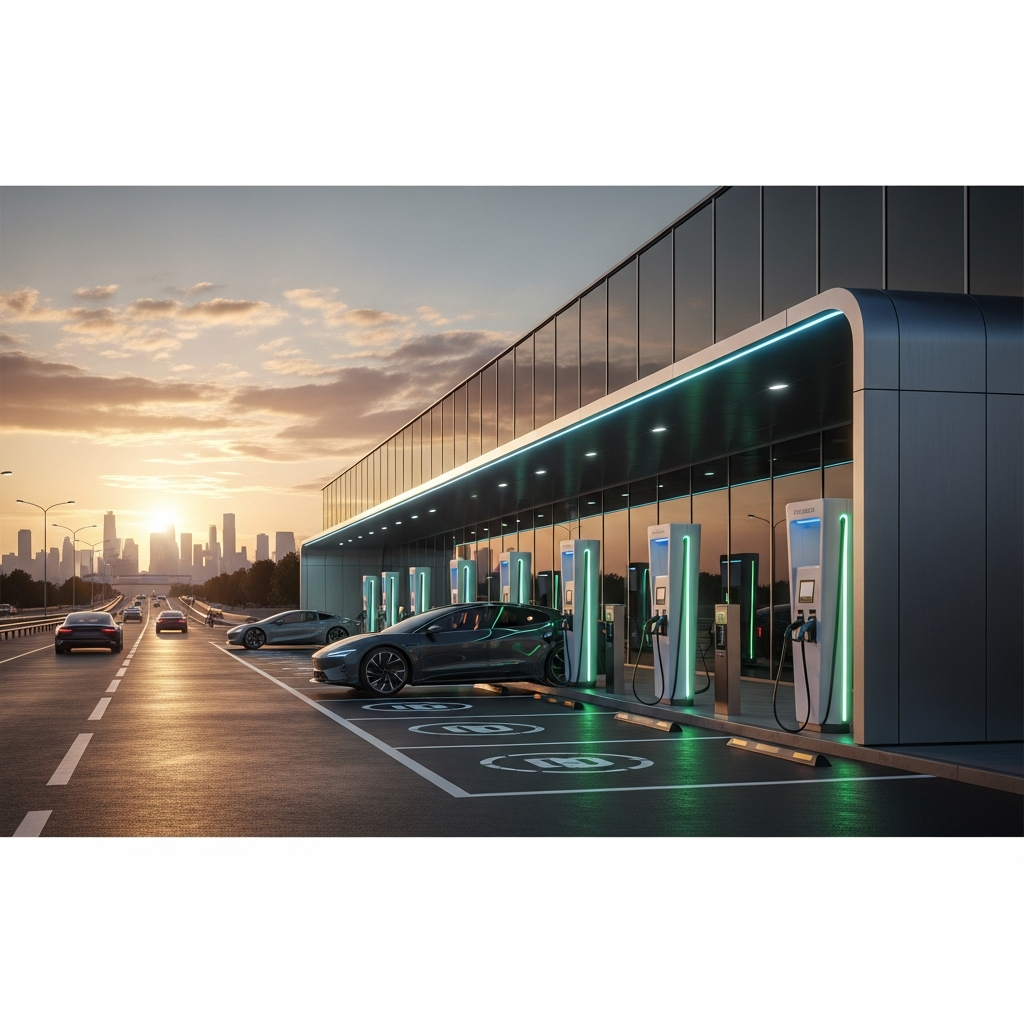

In [10]:
from IPython.display import Image, display

first_result = results[0]

print("Slug:", first_result.slug)
print("GCS URI:", first_result.gcs_uri)

downloaded_image_path = download_gcs_uri_to_local(
    gcs_uri=first_result.gcs_uri,
    output_dir=DOWNLOAD_DIR,
)

print("Downloaded to:", downloaded_image_path)
print("Exists:", downloaded_image_path.exists())

display(Image(filename=str(downloaded_image_path), width=420))

In [11]:
print("Google Cloud local setup validation completed successfully.")
print("Project ID:", PROJECT_ID)
print("Vertex AI location:", LOCATION)
print("Bucket:", BUCKET_NAME)
print("BigQuery dataset:", DATASET_ID)
print("BigQuery table:", TABLE_ID)
print("Local assets root:", ASSETS_ROOT)

Google Cloud local setup validation completed successfully.
Project ID: leafy-guide-497515-m4
Vertex AI location: us-central1
Bucket: leafy-guide-497515-m4-vector-assets
BigQuery dataset: vector_image_search
BigQuery table: visual_assets
Local assets root: /home/lipov/projects/Python_practice_sessions_05/vector_db/vector_db/assets
